# TP3

## Encontrar el logotipo de la gaseosa dentro de las imagenes provistas en *Material_TPs/TP3/images* a partir del template *Material_TPs/TP3/template*

* 1. (4 puntos) Obtener una deteccion del logo en cada imagen sin falsos positivos.
* 2. (4 puntos) Plantear y validar un algoritmo para multiples detecciones en la imagen *coca_multi.png* con el mismo template del item 1.
* 3. (2 puntos) Generalizar el algoritmo del item 2 para todas las imagenes.

Visualizar los resultados con bounding boxes en cada imagen mostrando el nivel de confianza de la deteccion.

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import supervision as sv

Lectura del template

Template shape: (175, 400)


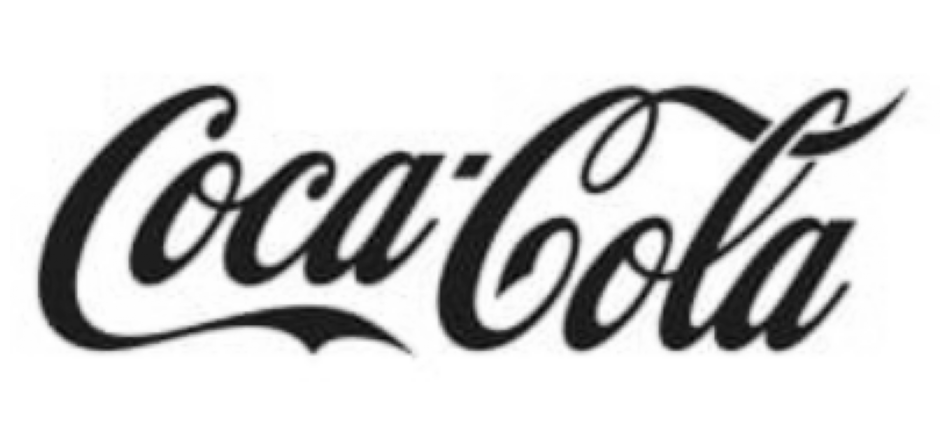

In [2]:
template = cv.imread('template/pattern.png')
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)
print(f"Template shape: {template_gray.shape}")
sv.plot_image(template_gray)

## Analisis caracteristias locales

### SIFT

In [3]:
sift = cv.SIFT_create()
kp, descriptors = sift.detectAndCompute(template_gray, None)
# tambien existe la version que se ejecuta sobre GPU
# siendo acelerada por CUDA
# https://docs.opencv.org/3.4/df/db9/classcv_1_1cuda_1_1Feature2DAsync.html#a56c6c75e25e9616934c25552164a363c

# Verificamos cuántas características encontró
print(f'Cantidad y dimension de los descriptores: {descriptors.shape}')
print(f'-- 1er keypoint -- ')
print(f'Orientacion: {kp[0].angle}')
print(f'Octava donde se encontro: {kp[0].octave}')
print(f'Posicion en la imagen: {kp[0].pt}')
print(f'Descriptores: {len(descriptors)}')
print(f'Keypoints: {len(kp)}')

dir(kp[0])[-10:]
print(descriptors[0])

Cantidad y dimension de los descriptores: (129, 128)
-- 1er keypoint -- 
Orientacion: 191.93084716796875
Octava donde se encontro: 11469569
Posicion en la imagen: (60.153263092041016, 108.77999877929688)
Descriptores: 129
Keypoints: 129
[  1.   1.  42.  32.   0.   0.   8.  18.   0.   2.  29.  42.   2.   5.
  50.  20.   0.   9.  33.  22.  17.  91.  75.   4.  20.  75.  34.   4.
  52.  84.   5.   0.  13.  59.  29.  30.   7.   1.  11.  39.   7.  29.
  87. 118.  38.   9.  15.  13.  69. 118.  64.  18.  48.  25.  10.   3.
  49.  14.   1.  15. 118.  44.   1.   2.  61. 113.  25.  19.  22.   8.
   0.   1.  33.  20.  13.  58. 114.  59.   2.  17. 118.  32.   5.  32.
  66.  11.   1.  60.  62.   2.   0.  69. 118.   0.   0.  28.  47.  21.
   4.  10.  24.   6.  14.  32.  34.   9.   7.  54.  39.   5.   5.  72.
  64.   0.   0.  75.  71.   1.   0.  89.  56.   0.   0.  58.  71.   0.
   0.  85.]


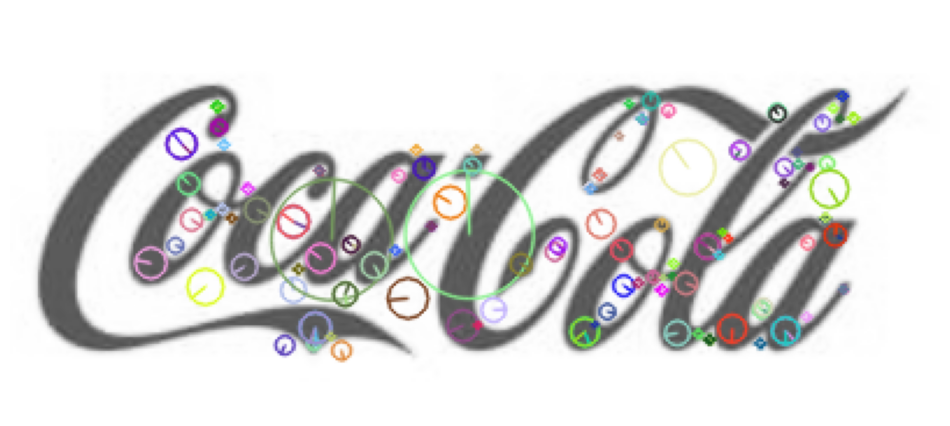

In [4]:
detalle = True
if detalle:
    # Dibujamos las características encontradas con más detalle
    template_2=cv.drawKeypoints(template_gray, kp, template_gray, flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
else:
    # Dibujamos las características encontradas sin mucho detalle
    template_2=cv.drawKeypoints(template_gray, kp, template_gray)
    
sv.plot_image(template_2)

### Fast

Umbral: 10
nonmaxSuppression:True
Vecindario: 2
Keypoints totales con nonmaxSuppression: 420


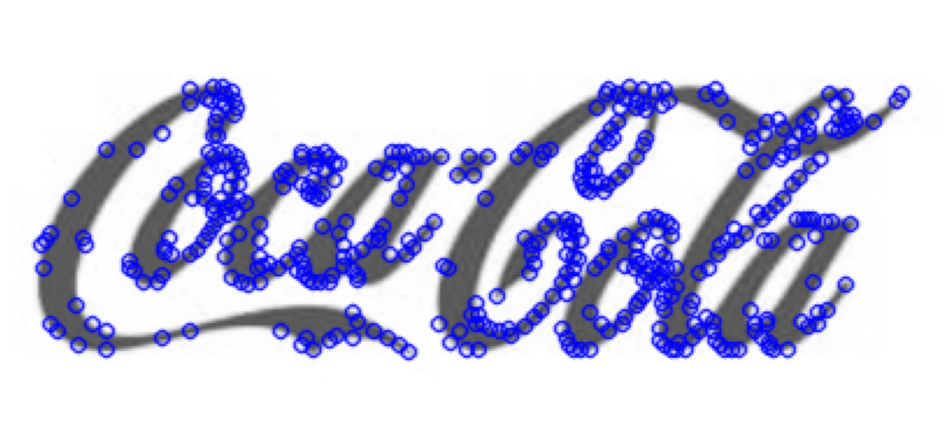

In [5]:
# Iniciamos el objeto FAST con valores por defecto
fast = cv.FastFeatureDetector_create()

# Encontramos y dibujamos los puntos clave (keypoints)
kp = fast.detect(template_gray, None)

# Devolvemos los valores por defecto
print( "Umbral: {}".format(fast.getThreshold()) )
print( "nonmaxSuppression:{}".format(fast.getNonmaxSuppression()) )
print( "Vecindario: {}".format(fast.getType()) )
print( "Keypoints totales con nonmaxSuppression: {}".format(len(kp)) )

# Graficamos
img2 = cv.drawKeypoints(template_gray, kp, None, color=(255,0,0))
sv.plot_image(img2)

### ORB

402


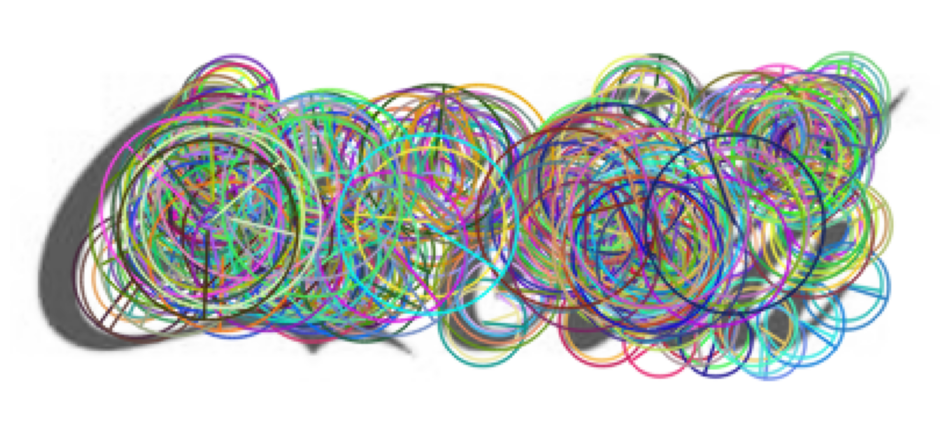

In [6]:
orb = cv.ORB_create()

# Encontramos los puntos clave (keypoints) - Es una versión de FAST
kp = orb.detect(template_gray, None)

# Calculamos los descriptores - Es una versión de BRIEF
kp, des = orb.compute(template_gray, kp)
# Verificamos cuántas características se encontraron
print(len(kp))

# Graficamos...
Detalle = True
if Detalle:
    # Dibujamos las características encontradas con más detalle
    img2=cv.drawKeypoints(template_gray,kp,template,flags=cv.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
else:
    # Dibujamos las características encontradas sin mucho detalle
    img2=cv.drawKeypoints(template_gray,kp,template)
    
sv.plot_image(img2)

## Comparación según los distintos métodos

In [7]:
def resize_template(image, template):
    template_resized = template.copy()
    if image.shape[0] < template.shape[0] or image.shape[1] < template.shape[1]:
        scale_percent = (template.shape[0] * 100) / image.shape[0]  # percent of original size
        scale_percent = scale_percent if scale_percent < (template.shape[1] * 100) / image.shape[1] else (template.shape[1] * 100) / image.shape[1]  # percent of original size
        print(f"Resizing template to {scale_percent}%")
        width = int(template.shape[1] * scale_percent / 100)
        height = int(template.shape[0] * scale_percent / 100)
        dim = (width, height)
        template_resized = cv.resize(template, dim, interpolation = cv.INTER_AREA)
    return template_resized

In [8]:
def resize_template_piramidal(image, template):

    template_resized = template.copy()
    while image.shape[0] < template_resized.shape[0] or image.shape[1] < template_resized.shape[1]:
        template_resized = cv.pyrDown(template_resized)
        
    return template_resized

In [10]:
def matches_img(template, image, print_details=False):
    methods = ['cv.TM_CCOEFF', 'cv.TM_CCOEFF_NORMED', 'cv.TM_CCORR',
            'cv.TM_CCORR_NORMED', 'cv.TM_SQDIFF', 'cv.TM_SQDIFF_NORMED']
    images = []
    template_resized = resize_template(image, template)
    w, h = template_resized.shape[::-1]
    for meth in methods:
        print_details and print(f"Method: {meth}")
        # Hago una copia de la imagen porque ciclo a ciclo le dibujo rectángulos
        img_salida = image.copy()
        
        method = eval(meth)
        
        # Aplicamos la coincidencia de patrones
        #--------------------------------------
        res = cv.matchTemplate(image, template_resized, method)
        print_details and print(f"Result shape: {res.shape}")
        # Encontramos los valores máximos y mínimos
        min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)
        
        # Si el método es TM_SQDIFF o TM_SQDIFF_NORMED, tomamos el mínimo
        if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
            top_left = min_loc
        else:
            top_left = max_loc
        
        # Marcamos el lugar donde lo haya encontrado
        #----------------------------------------
        bottom_right = (top_left[0] + w, top_left[1] + h)
        cv.rectangle(img_salida,top_left, bottom_right, 255, 2)
        cropped_img = image[top_left[1]:top_left[1]+h, top_left[0]:top_left[0]+w]

        images.append(cropped_img)
        # Graficamos el procesamiento y la salida
        #----------------------------------------
        if print_details:
            plt.figure()

            plt.subplot(151)
            plt.imshow(image,cmap = 'gray')
            plt.title('Image')

            plt.subplot(152)
            plt.imshow(template,cmap = 'gray')
            plt.title('template')

            # Resultado de coincidencia
            plt.subplot(153)
            plt.imshow(res,cmap = 'gray')
            plt.title('Matching Result')
            
            # Imagen original con recuadros
            plt.subplot(154)
            plt.imshow(img_salida)
            plt.title('Detected Point')
            
            plt.subplot(155)
            plt.imshow(cropped_img, cmap='gray')
            plt.title('Imagen recortada')

            plt.suptitle(meth)
            plt.show()
    return template_resized, images

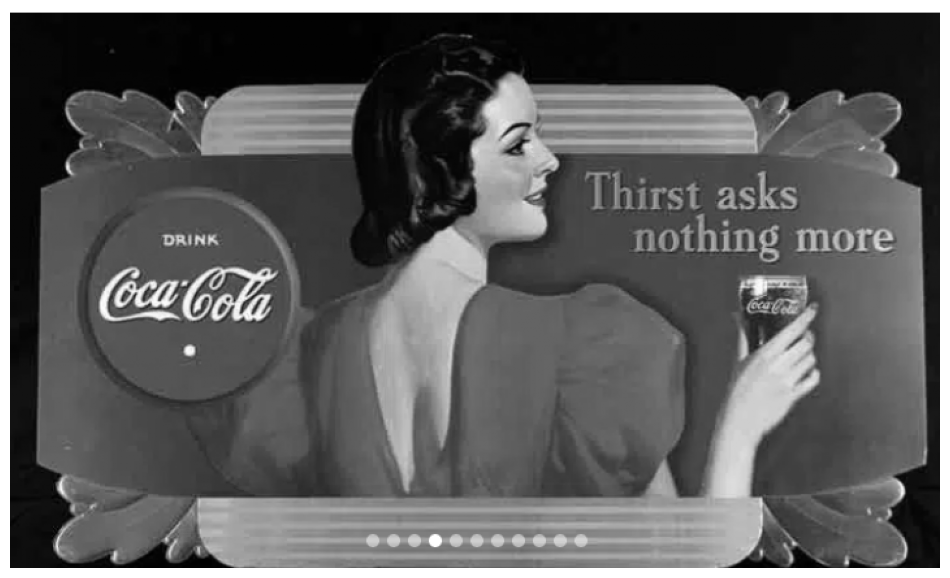

In [79]:
image_1 = cv.imread('imagenes/coca_retro_2.png')
img_rgb= cv.cvtColor(image_1, cv.COLOR_BGR2RGB)
image_gray = cv.cvtColor(image_1, cv.COLOR_BGR2GRAY)
sv.plot_image(image_gray)

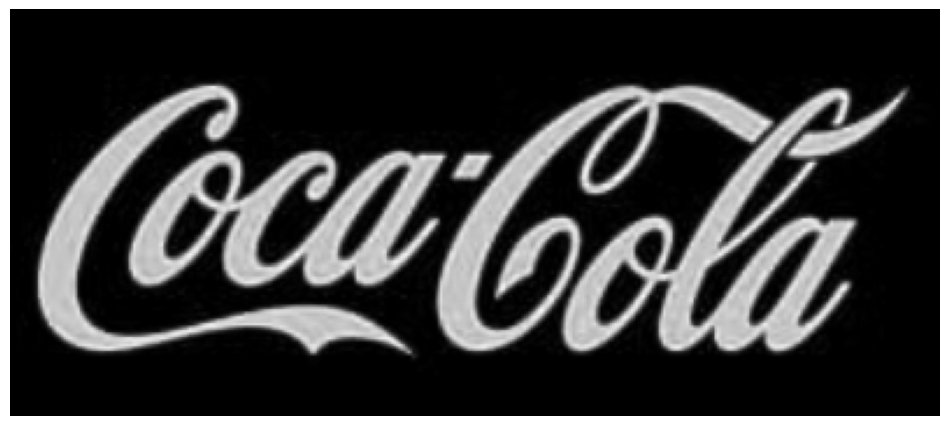

In [80]:
imagen_invertida = cv.bitwise_not(template_gray)
sv.plot_image(imagen_invertida)

In [ ]:
matches_img(imagen_invertida, image_gray, print_details=True)

## Correspondencia de Características (Match)

In [95]:
# Cargamos template de la máscara
template_gray = cv.imread('template/pattern.png', cv.IMREAD_GRAYSCALE)
template_gray_inverted = cv.bitwise_not(template_gray)
# Cargamos la imagen de búsqueda
img_gray_1 = cv.imread('imagenes/coca_retro_2.png', cv.IMREAD_GRAYSCALE)

### Orb

In [83]:
orb = cv.ORB_create()

# find the keypoints and descriptors with ORB
kp1_orb, des1_orb = orb.detectAndCompute(template_gray,None)
kp2_orb, des2_orb = orb.detectAndCompute(template_gray_inverted,None)
kp3_orb, des3_orb = orb.detectAndCompute(img_gray_1,None)

print(len(kp1_orb))
print(len(kp2_orb))
print(len(kp3_orb))

394
394
500


### SIFT

In [84]:
sift = cv.SIFT_create()

# Y buscamos según el algoritmo...
kp1_sift, des1_sift = sift.detectAndCompute(template_gray,None)
kp2_sift, des2_sift = sift.detectAndCompute(template_gray_inverted,None)
kp3_sift, des3_sift = sift.detectAndCompute(img_gray_1,None)

print(len(kp1_sift))
print(len(kp2_sift))
print(len(kp3_sift))

211
211
1238


### Surf

In [17]:
surf = cv.xfeatures2d.SURF_create()
kp1_surf, des1_surf = surf.detectAndCompute(template_gray,None)
kp2_surf, des2_surf = surf.detectAndCompute(template_gray_inverted,None)
kp3_surf, des3_surf = surf.detectAndCompute(img_gray_1,None)

print(len(kp1_surf))
print(len(kp2_surf))
print(len(kp3_surf))

AttributeError: module 'cv2' has no attribute 'xfeatures2d'

### Maches

In [70]:
def match_fuerza_bruta(template, image, alg, mask=None):
    kp1, des1 = alg.detectAndCompute(template,None)
    kp2, des2 = alg.detectAndCompute(image,mask)
    print(len(kp1))
    print(len(kp2))
    # create BFMatcher object
    bf = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=True)
    print(des1.shape)
    print(des2.shape)
    # Match descriptors.
    matches = bf.match(des1,des2)

    # Sort them in the order of their distance.
    matches = sorted(matches, key = lambda x:x.distance)
    
    return matches, kp1, kp2

def match_fuerza_bruta_knn(template, image, alg, mask=None, percent=0.8):
    kp1, des1 = alg.detectAndCompute(template,None)
    kp2, des2 = alg.detectAndCompute(image,mask)
    print(len(kp1))
    print(len(kp2))
    # create BFMatcher object
    bf = cv.BFMatcher()

    # Match descriptors.
    matches = bf.knnMatch(des1,des2, k=2)
 
    good = []
    for m, n in matches:
        if m.distance < percent*n.distance:
            good.append(m)

    # Los ordenamos según distancia
    good = sorted(good, key = lambda x:x.distance)

    return good, kp1, kp2

def match_flann_knn(template, image, alg, mask=None, percent=0.8):
    kp1, des1 = alg.detectAndCompute(template,None)
    kp2, des2 = alg.detectAndCompute(image,mask)
    print(len(kp1))
    print(len(kp2))
    # FLANN parameters
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    search_params = dict(checks=50)   # or pass empty dictionary

    flann = cv.FlannBasedMatcher(index_params,search_params)
    print(des1.shape)
    print(des2.shape)
    matches = flann.knnMatch(des1,des2,k=2)

    good = []
    for m,n in matches:
        if m.distance < percent*n.distance:
            good.append(m)

    return good, kp1, kp2

In [87]:
def evaluate_matches(template, image, percent=0.8):
    matches_1, kp1_1, kp2_1 = match_fuerza_bruta(template, image, orb)
    print(f"match_fuerza_bruta + orb: {len(matches_1)}")

    matches_3, kp1_3, kp2_3 = match_fuerza_bruta_knn(template, image, orb, percent=percent)
    print(f"match_fuerza_bruta_knn + orb: {len(matches_3)}")

    matches_4, kp1_4, kp2_4 = match_fuerza_bruta_knn(template, image, sift, percent=percent)
    print(f"match_fuerza_bruta_knn + sift: {len(matches_4)}")

    #matches_5, kp1_5, kp2_5 = match_flann_knn(template, image, orb, percent=percent)
    #print(f"Cantidad de coincidencias buenas: {len(matches_5)}")

    matches_6, kp1_6, kp2_6 = match_flann_knn(template, image, sift, percent=percent)
    print(f"match_flann_knn + sift: {len(matches_6)}")



In [88]:
evaluate_matches(template_gray_inverted, img_gray_1, percent=0.9)
evaluate_matches(template_gray, img_gray_1, percent=0.9)

394
500
(394, 32)
(500, 32)
match_fuerza_bruta + orb: 125
394
500
match_fuerza_bruta_knn + orb: 65
211
1238
match_fuerza_bruta_knn + sift: 63
211
1238
(211, 128)
(1238, 128)
match_flann_knn + sift: 69
394
500
(394, 32)
(500, 32)
match_fuerza_bruta + orb: 109
394
500
match_fuerza_bruta_knn + orb: 64
211
1238
match_fuerza_bruta_knn + sift: 36
211
1238
(211, 128)
(1238, 128)
match_flann_knn + sift: 47


In [ ]:
#matches_1, kp1_1, kp2_1 = match_flann_knn(template_gray, img_gray_1, sift, percent=0.85)
matches_1, kp1_1, kp2_1 = match_fuerza_bruta(template_gray_inverted, img_gray_1, orb)
# Dibujamos las primeras 30 coincidencias
n=50
img3 = cv.drawMatches(template_gray_inverted,kp1_1,img_gray_1,kp2_1,matches_1[:n],None,flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
sv.plot_image(img3)

template_resized, images = matches_img(template_gray_inverted, img_gray_1, print_details=True)
for i, cropped_img in enumerate(images):
    print(f"Imagen recortada {i}: {cropped_img}")
    print(f"Imagen real: {img_gray_1}")
    matches, kp1, kp2 = match_fuerza_bruta(template_gray_inverted, cropped_img, orb)
    img3 = cv.drawMatches(template_gray_inverted,kp1,img_gray_1,kp2,matches[:n],None,flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    sv.plot_image(img3)

394
500
(394, 32)
(500, 32)


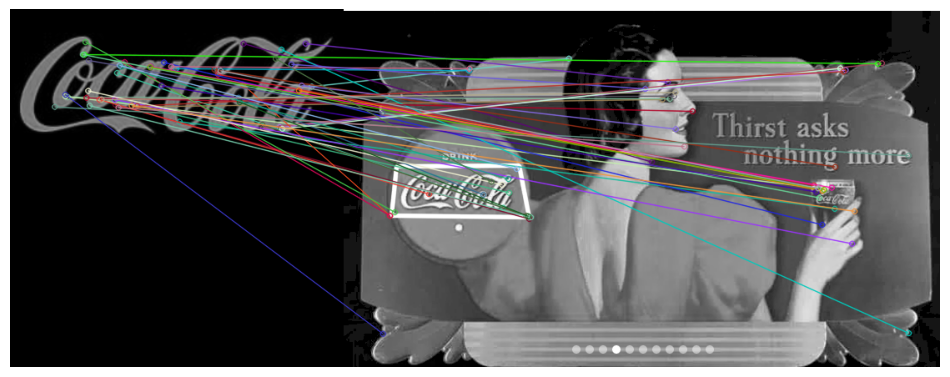

In [94]:
#matches_1, kp1_1, kp2_1 = match_flann_knn(template_gray, img_gray_1, sift, percent=0.85)
matches_1, kp1_1, kp2_1 = match_fuerza_bruta(template_gray_inverted, img_gray_1, orb)
# Dibujamos las primeras N coincidencias (las mejores)
N = 50
# cv.drawMatchesKnn espera una lista de listas como coincidencias
img3 = cv.drawMatchesKnn(template_gray_inverted, kp1_1, img_gray_1, kp2_1, [matches_1[:N]], None, flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
#img3 = cv.drawMatchesKnn(img1,kp1,img2,kp2,good,None,flags=cv.DrawMatchesFlags_DEFAULT)
sv.plot_image(img3)

In [ ]:
good_matches = [m for idx, m in enumerate(good_matches) if matches_mask[idx] == 0]

### FLANN (Fast Library for Approximate Nearest Neighbors)

In [92]:
# parámetros FLANN
FLANN_INDEX_KDTREE = 1

index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict()   # o pasar un diccionario vacío
flann = cv.FlannBasedMatcher(index_params,search_params)
# K es la cantidad de "best matches" para cada descriptor
matches = flann.knnMatch(des1, des2, k=2)

# Necesidad de dibujar solo las coincidencias buenas, se crea una máscara
matchesMask = [[0,0] for i in range(len(matches))]

# Ratio de verificación como figura en el paper de Lowe
for i,(m,n) in enumerate(matches):
    if m.distance < 0.85*n.distance:
        matchesMask[i]=[1,0]
draw_params = dict(matchColor = (0,255,0),
                   singlePointColor = (255,0,0),
                   matchesMask = matchesMask,
                   flags = cv.DrawMatchesFlags_DEFAULT)
img3 = cv.drawMatchesKnn(template_gray,kp1,img_gray_1,kp2,matches,None,**draw_params)
sv.plot_image(img3)

NameError: name 'des1' is not defined

### FLANN + Homografía

In [75]:
MIN_MATCH_COUNT = 8
def draw_matches_with_homography(template, img, kp1, kp2, good, min_match_count=MIN_MATCH_COUNT):
    
    if len(good) > min_match_count:
        src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
        dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)
        M, mask = cv.findHomography(src_pts, dst_pts, cv.RANSAC, 5.0)
        matchesMask = mask.ravel().tolist()
        h,w = template.shape
        pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
        dst = cv.perspectiveTransform(pts, M)
        img_2 = cv.polylines(img, [np.int32(dst)], True, 255, 3, cv.LINE_AA)
    else:
        print( "No se encontraron suficientes coincidencias - {}/{}".format(len(good), min_match_count) )
        matchesMask = None

    print(f"Cantidad de coincidencias buenas: {len(matchesMask)}")
    draw_params = dict(matchColor = (0,255,0), # dibujar coincidencias en verde
                    singlePointColor = None,
                    matchesMask = matchesMask, # dibujar solo inliers
                    flags = 2)
    print(f"Cantidad de coincidencias buenas: {len(matchesMask)}")
    img3 = cv.drawMatches(template, kp1, img_2, kp2, good, None, **draw_params)
    sv.plot_image(img3)

Cantidad de coincidencias buenas: 36
Cantidad de coincidencias buenas: 36


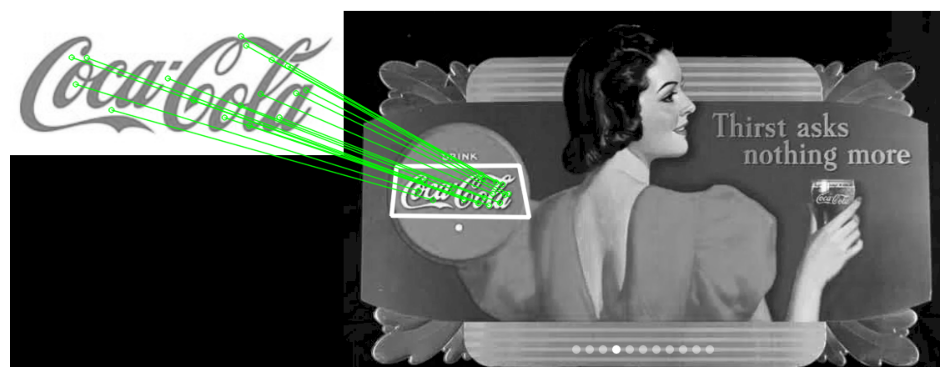

In [91]:
draw_matches_with_homography(template_gray, img_gray_1, kp1_1, kp2_1, matches_1)

## Testeamos todas las imagenes

Procesando imagen: coca_logo_1.png
211
289
(211, 128)
(289, 128)
211
289
(211, 128)
(289, 128)
Cantidad de coincidencias buenas: 19
Cantidad de coincidencias buenas: 52
Usando template invertido para la imagen: coca_logo_1.png
Cantidad de coincidencias buenas: 52
Cantidad de coincidencias buenas: 52


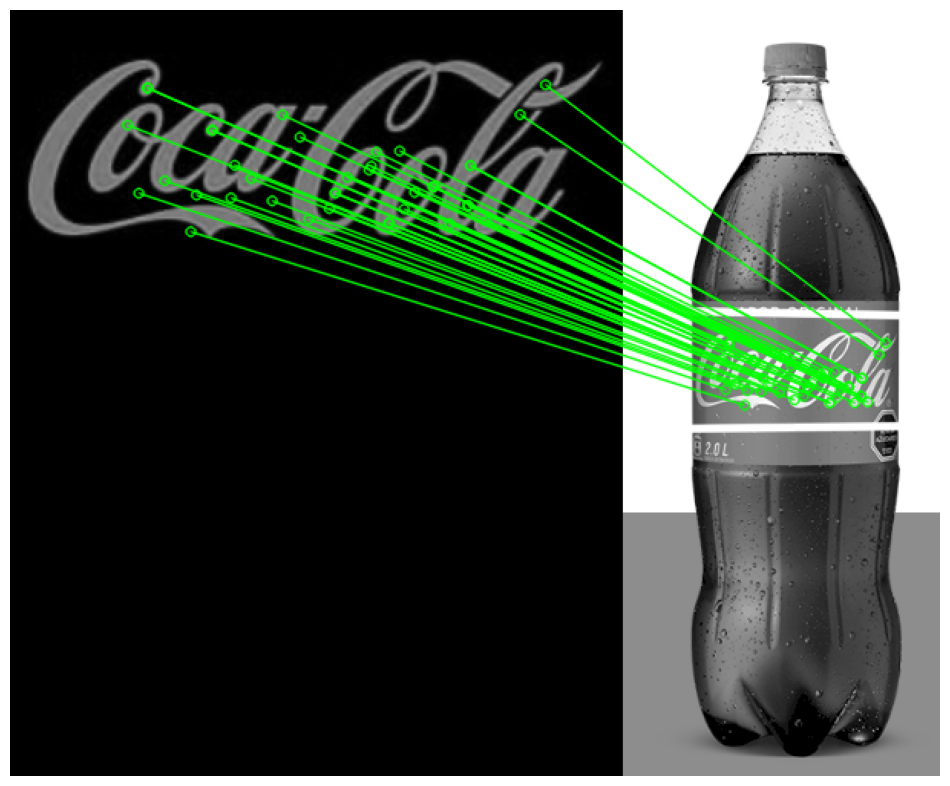

Procesando imagen: coca_logo_2.png
211
615
(211, 128)
(615, 128)
211
615
(211, 128)
(615, 128)
Cantidad de coincidencias buenas: 14
Cantidad de coincidencias buenas: 51
Usando template invertido para la imagen: coca_logo_2.png
Cantidad de coincidencias buenas: 51
Cantidad de coincidencias buenas: 51


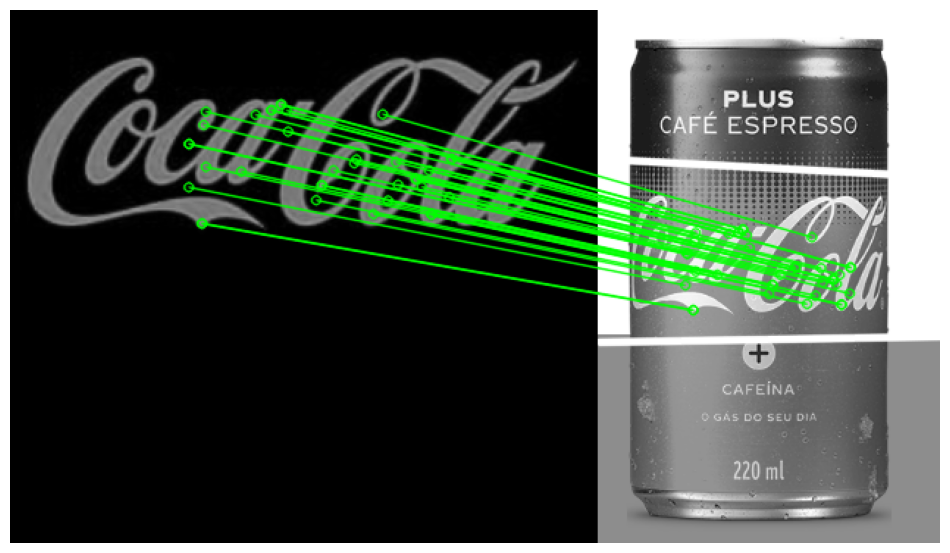

Procesando imagen: coca_multi.png
211
4046
(211, 128)
(4046, 128)
211
4046
(211, 128)
(4046, 128)
Cantidad de coincidencias buenas: 6
Cantidad de coincidencias buenas: 14
Usando template invertido para la imagen: coca_multi.png
Cantidad de coincidencias buenas: 14
Cantidad de coincidencias buenas: 14


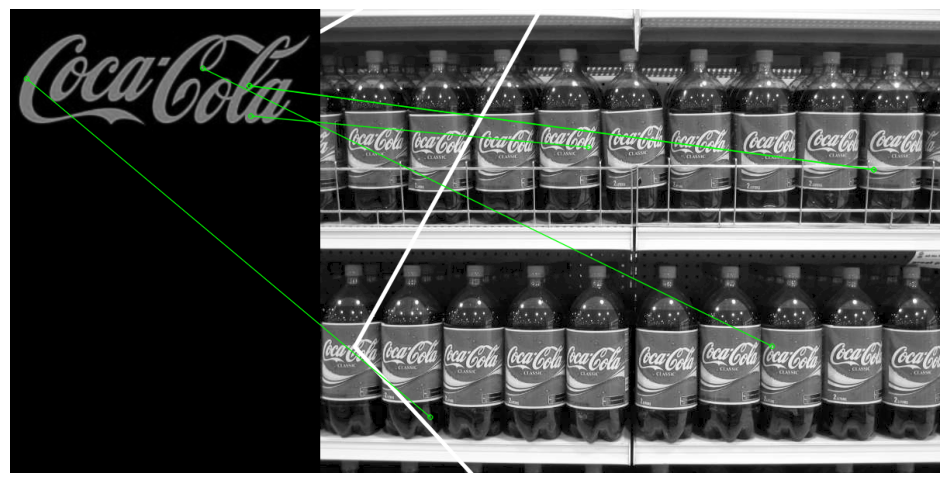

Procesando imagen: coca_retro_1.png
211
3892
(211, 128)
(3892, 128)
211
3892
(211, 128)
(3892, 128)
Cantidad de coincidencias buenas: 56
Cantidad de coincidencias buenas: 13
Usando template original para la imagen: coca_retro_1.png
Cantidad de coincidencias buenas: 56
Cantidad de coincidencias buenas: 56


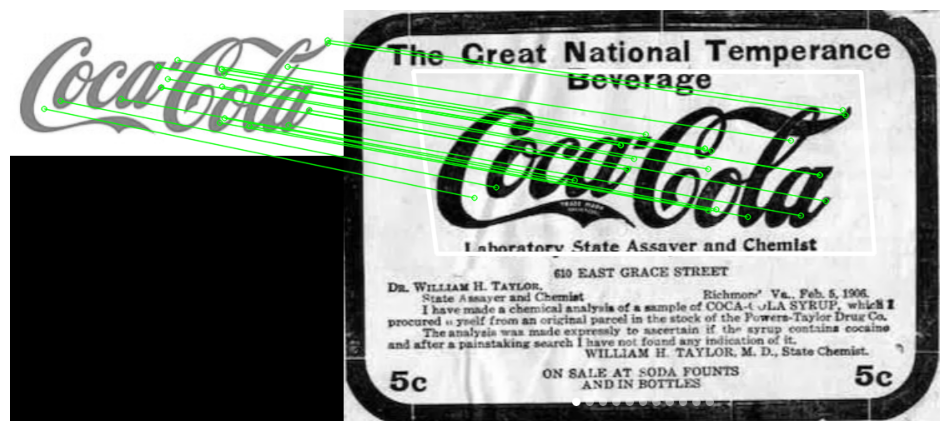

Procesando imagen: coca_retro_2.png
211
1238
(211, 128)
(1238, 128)
211
1238
(211, 128)
(1238, 128)
Cantidad de coincidencias buenas: 11
Cantidad de coincidencias buenas: 23
Usando template invertido para la imagen: coca_retro_2.png
Cantidad de coincidencias buenas: 23
Cantidad de coincidencias buenas: 23


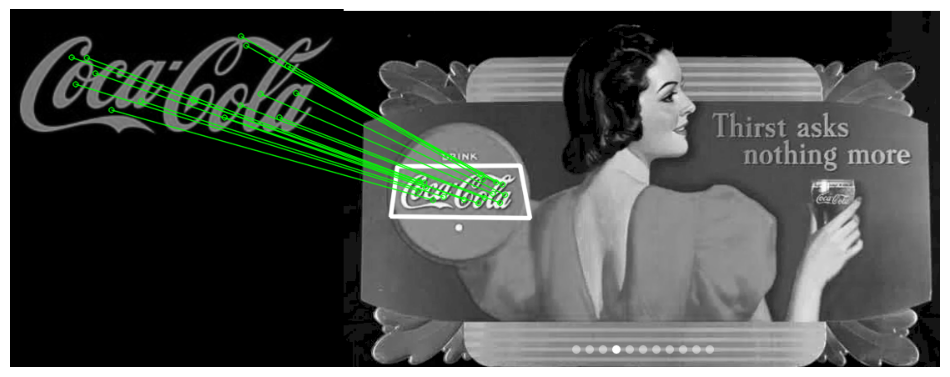

Procesando imagen: COCA-COLA-LOGO.jpg
211
2848
(211, 128)
(2848, 128)
211
2848
(211, 128)
(2848, 128)
Cantidad de coincidencias buenas: 26
Cantidad de coincidencias buenas: 63
Usando template invertido para la imagen: COCA-COLA-LOGO.jpg
Cantidad de coincidencias buenas: 63
Cantidad de coincidencias buenas: 63


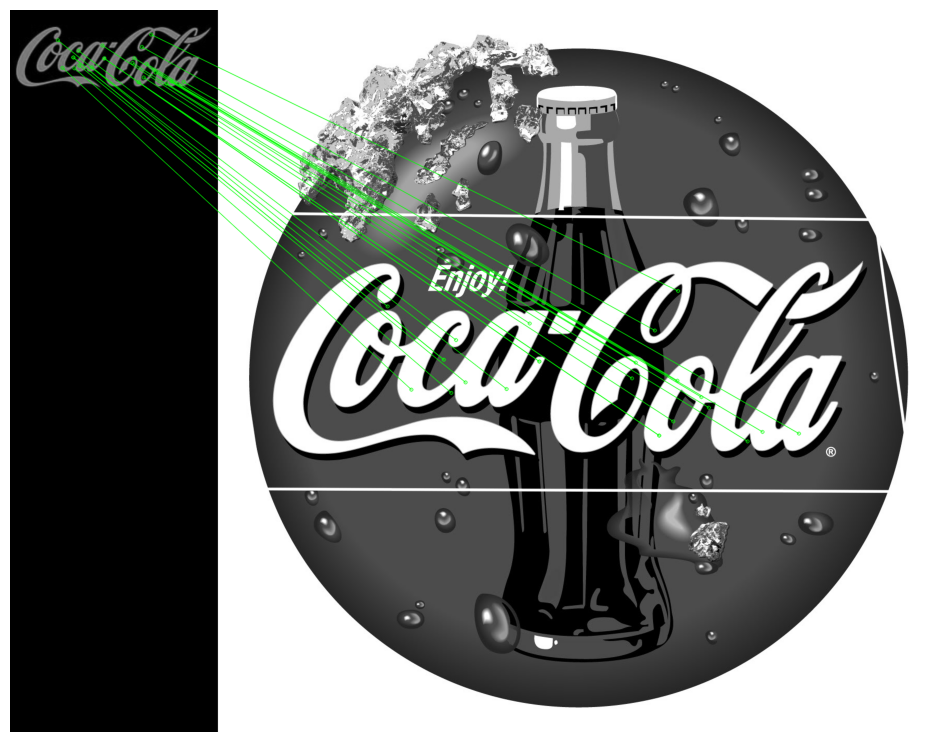

Procesando imagen: logo_1.png
211
463
(211, 128)
(463, 128)
211
463
(211, 128)
(463, 128)
Cantidad de coincidencias buenas: 8
Cantidad de coincidencias buenas: 65
Usando template invertido para la imagen: logo_1.png
Cantidad de coincidencias buenas: 65
Cantidad de coincidencias buenas: 65


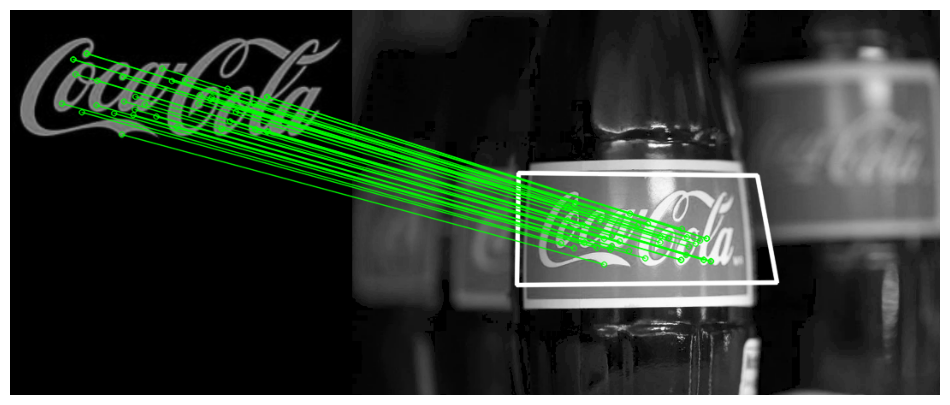

In [78]:
images = ["coca_logo_1.png", "coca_logo_2.png", "coca_multi.png", "coca_retro_1.png", "coca_retro_2.png", "COCA-COLA-LOGO.jpg", "logo_1.png"]
for image_name in images:
    print(f"Procesando imagen: {image_name}")
    image_path = f"imagenes/{image_name}"
    img_gray = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    #evaluate_matches(template_gray_inverted, img_gray)
    matches_1, kp1_1, kp2_1 = match_flann_knn(template_gray, img_gray, sift, percent=0.8)
    matches_2, kp1_2, kp2_2 = match_flann_knn(template_gray_inverted, img_gray, sift, percent=0.8)
    print(f"Cantidad de coincidencias buenas: {len(matches_1)}")
    print(f"Cantidad de coincidencias buenas: {len(matches_2)}")
    if len(matches_1) > len(matches_2):
        print(f"Usando template original para la imagen: {image_name}")
        draw_matches_with_homography(template_gray, img_gray, kp1_1, kp2_1, matches_1)
    else:
        print(f"Usando template invertido para la imagen: {image_name}")
        draw_matches_with_homography(template_gray_inverted, img_gray, kp1_2, kp2_2, matches_2)